# 02. EDA general del corpus RTVE 23-F

Este notebook recoge el análisis exploratorio general del corpus documental del 23-F construido a partir de RTVE.

La idea aquí es entender bien qué datos tenemos, cómo están estructurados y qué limitaciones presentan.

En este EDA se revisan principalmente:

- cuántos documentos forman el corpus;
- si las tablas principales están bien relacionadas;
- si todos los documentos tienen texto disponible;
- cómo se distribuyen las páginas, palabras y caracteres;
- si existen documentos especialmente cortos o largos;
- qué señales básicas aparecen sobre la calidad del OCR;
- cómo se reparte el corpus por procedencia institucional;
- qué utilidad real tienen campos como `summary` y `keywords`.

Este notebook debe entenderse como una revisión general de datos. No sustituye al EDA específico que después pueda necesitar cada mini caso.

También es importante separar este análisis de cualquier preprocesado propio de modelos. En este cuaderno se pueden calcular métricas descriptivas, revisar distribuciones y detectar posibles problemas, pero no se deben ajustar transformaciones que después se usen directamente en entrenamiento. Por ejemplo, un TF-IDF, un escalado, una imputación, un balanceo de clases o una selección de variables deberán hacerse dentro del pipeline de cada mini caso y, si hay modelos supervisados, ajustarse solo con el conjunto de train.

Por tanto, el objetivo de este notebook es dejar una visión clara y honesta del corpus.

## 1. Carga inicial de tablas

El primer paso consiste en cargar las tablas generadas en el notebook anterior de construcción del corpus. En este punto no se modifica todavía ningún dato: solo se leen los archivos disponibles y se comprueba qué estructura tienen.

Las tablas principales son:

- `inventory_rtve.csv`: inventario de documentos RTVE, con identificador, título, páginas, resumen, palabras clave y enlaces.
- `document_texts_rtve.csv`: texto OCR asociado a cada documento.
- `inventory_moncloa.csv`: inventario procedente de La Moncloa, usado como fuente institucional de contraste.
- `source_comparison.csv`: tabla de correspondencias entre documentos de RTVE y La Moncloa.

La carga se hace con rutas relativas para que el notebook pueda ejecutarse desde el repositorio sin depender de una ruta fija del ordenador.

In [5]:
from pathlib import Path

import pandas as pd

# Localización robusta de la raíz del repositorio
# La idea es que funcione aunque el notebook se ejecute desde /notebooks o desde la raíz.
current_path = Path.cwd().resolve()

if (current_path / "data").exists() and (current_path / "notebooks").exists():
    ROOT = current_path
elif (current_path.parent / "data").exists() and (current_path.parent / "notebooks").exists():
    ROOT = current_path.parent
else:
    raise FileNotFoundError(
        "No se ha podido localizar la raíz del repositorio. "
        "Comprueba desde dónde se está ejecutando el notebook."
    )

DATA_INTERIM = ROOT / "data" / "interim"

# Rutas de entrada
path_inventory_rtve = DATA_INTERIM / "inventory_rtve.csv"
path_document_texts_rtve = DATA_INTERIM / "document_texts_rtve.csv"
path_inventory_moncloa = DATA_INTERIM / "inventory_moncloa.csv"
path_source_comparison = DATA_INTERIM / "source_comparison.csv"

# Carga de tablas principales
inventory_rtve = pd.read_csv(path_inventory_rtve)
document_texts_rtve = pd.read_csv(path_document_texts_rtve)
inventory_moncloa = pd.read_csv(path_inventory_moncloa)
source_comparison = pd.read_csv(path_source_comparison)

# Comprobación básica de carga
print(f"ROOT: {ROOT}")

print("\nDimensiones de las tablas cargadas:")
print(f"inventory_rtve:        {inventory_rtve.shape}")
print(f"document_texts_rtve:   {document_texts_rtve.shape}")
print(f"inventory_moncloa:     {inventory_moncloa.shape}")
print(f"source_comparison:     {source_comparison.shape}")

print("\nColumnas inventory_rtve:")
print(inventory_rtve.columns.tolist())

print("\nColumnas document_texts_rtve:")
print(document_texts_rtve.columns.tolist())

display(inventory_rtve.head())
display(document_texts_rtve.head())

ROOT: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos

Dimensiones de las tablas cargadas:
inventory_rtve:        (167, 9)
document_texts_rtve:   (167, 7)
inventory_moncloa:     (156, 9)
source_comparison:     (155, 19)

Columnas inventory_rtve:
['doc_id', 'source', 'source_document_id', 'title', 'pages', 'summary', 'keywords', 'detail_url', 'pdf_url']

Columnas document_texts_rtve:
['doc_id', 'text_full', 'text_length_chars', 'text_length_words', 'extraction_source', 'text_extraction_ok', 'pdf_url']


,doc_id,source,source_document_id,title,pages,summary,keywords,detail_url,pdf_url
0,rtve_1860,rtve_buscador,1860,Vista oral 2/81 del Consejo Supremo de Justici...,3,El juicio oral 2/81 celebrado en febrero de 19...,C/SG/2820/20-02-82 DTOR. Vista oral 2/81,https://23fbuscador.rtve.es/document/ocr/1860?...,https://www.rtve.es/contenidos/documentos/23f-...
1,rtve_1859,rtve_buscador,1859,Vista oral 2/81 del Consejo Supremo de Justici...,4,Resumen global del documento:\n\nEl documento ...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...,https://23fbuscador.rtve.es/document/ocr/1859?...,https://www.rtve.es/contenidos/documentos/23f-...
2,rtve_1858,rtve_buscador,1858,Vista oral 2/81 del Consejo Supremo de Justici...,5,Resumen global del documento:\n\nEl documento ...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...,https://23fbuscador.rtve.es/document/ocr/1858?...,https://www.rtve.es/contenidos/documentos/23f-...
3,rtve_1857,rtve_buscador,1857,Vista oral 2/81 del Consejo Supremo de Justici...,6,El documento recoge el desarrollo de la sesión...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...,https://23fbuscador.rtve.es/document/ocr/1857?...,https://www.rtve.es/contenidos/documentos/23f-...
4,rtve_1856,rtve_buscador,1856,Vista oral 2/81 del Consejo Supremo de Justici...,6,Resumen global del documento sobre la sesión d...,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...,https://23fbuscador.rtve.es/document/ocr/1856?...,https://www.rtve.es/contenidos/documentos/23f-...


,doc_id,text_full,text_length_chars,text_length_words,extraction_source,text_extraction_ok,pdf_url
0,rtve_1860,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,3934,640,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...
1,rtve_1859,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,6417,1018,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...
2,rtve_1858,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,8183,1347,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...
3,rtve_1857,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,11151,1826,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...
4,rtve_1856,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,10124,1740,rtve_detail_html_pre,True,https://www.rtve.es/contenidos/documentos/23f-...


## 2. Validación de integridad del corpus

Antes de analizar contenido o hacer gráficos, conviene comprobar que las tablas principales encajan entre sí.

En este bloque se revisa:

- si el inventario RTVE y la tabla de textos tienen el mismo número de documentos;
- si existen `doc_id` duplicados;
- si hay documentos del inventario sin texto OCR asociado;
- si hay textos sin documento correspondiente en el inventario;
- si algún texto aparece vacío;
- si la extracción OCR consta como correcta.

Esta parte comprueba que la base de trabajo sea consistente.

In [6]:
print("=== VALIDACIÓN DE INTEGRIDAD DEL CORPUS ===\n")

# 1. Dimensiones básicas
print("Dimensiones principales:")
print(f"Inventario RTVE: {inventory_rtve.shape}")
print(f"Textos RTVE:     {document_texts_rtve.shape}")

# 2. Duplicados por identificador
duplicados_inventory = inventory_rtve["doc_id"].duplicated().sum()
duplicados_texts = document_texts_rtve["doc_id"].duplicated().sum()

print("\nDuplicados en doc_id:")
print(f"Duplicados en inventory_rtve:      {duplicados_inventory}")
print(f"Duplicados en document_texts_rtve: {duplicados_texts}")

# 3. Cruce entre inventario y textos
ids_inventory = set(inventory_rtve["doc_id"])
ids_texts = set(document_texts_rtve["doc_id"])

docs_sin_texto = sorted(ids_inventory - ids_texts)
textos_sin_doc = sorted(ids_texts - ids_inventory)

print("\nCruce entre inventario y textos:")
print(f"Documentos en inventario sin texto: {len(docs_sin_texto)}")
print(f"Textos sin documento en inventario: {len(textos_sin_doc)}")

# 4. Estado de extracción OCR
ocr_status = (
    document_texts_rtve["text_extraction_ok"]
    .value_counts(dropna=False)
    .rename_axis("text_extraction_ok")
    .reset_index(name="n_documentos")
)

print("\nEstado de extracción OCR:")
display(ocr_status)

# 5. Textos vacíos o prácticamente vacíos
textos_vacios = document_texts_rtve[
    document_texts_rtve["text_full"].fillna("").str.strip().eq("")
]

print("\nTextos vacíos:")
print(len(textos_vacios))

# 6. Resumen de longitudes textuales
length_summary = document_texts_rtve[
    ["text_length_chars", "text_length_words"]
].describe()

print("\nResumen de longitudes textuales:")
display(length_summary)

# 7. Tabla unificada para el resto del EDA
df_corpus = inventory_rtve.merge(
    document_texts_rtve,
    on=["doc_id", "pdf_url"],
    how="left",
    validate="one_to_one"
)

print("\nTabla unificada para el EDA:")
print(df_corpus.shape)

print("\nColumnas disponibles:")
print(df_corpus.columns.tolist())

display(df_corpus.head())

=== VALIDACIÓN DE INTEGRIDAD DEL CORPUS ===

Dimensiones principales:
Inventario RTVE: (167, 9)
Textos RTVE:     (167, 7)

Duplicados en doc_id:
Duplicados en inventory_rtve:      0
Duplicados en document_texts_rtve: 0

Cruce entre inventario y textos:
Documentos en inventario sin texto: 0
Textos sin documento en inventario: 0

Estado de extracción OCR:


,text_extraction_ok,n_documentos
0,True,167



Textos vacíos:
0

Resumen de longitudes textuales:


,text_length_chars,text_length_words
count,167.000000,167.000000
mean,11675.892216,2075.443114
std,37822.711182,7731.242472
min,455.000000,72.000000
25%,1495.500000,238.500000
50%,3529.000000,579.000000
75%,10524.000000,1771.500000
max,453130.000000,95293.000000



Tabla unificada para el EDA:
(167, 14)

Columnas disponibles:
['doc_id', 'source', 'source_document_id', 'title', 'pages', 'summary', 'keywords', 'detail_url', 'pdf_url', 'text_full', 'text_length_chars', 'text_length_words', 'extraction_source', 'text_extraction_ok']


,doc_id,source,source_document_id,title,pages,summary,keywords,detail_url,pdf_url,text_full,text_length_chars,text_length_words,extraction_source,text_extraction_ok
0,rtve_1860,rtve_buscador,1860,Vista oral 2/81 del Consejo Supremo de Justici...,3,El juicio oral 2/81 celebrado en febrero de 19...,C/SG/2820/20-02-82 DTOR. Vista oral 2/81,https://23fbuscador.rtve.es/document/ocr/1860?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/2820/20-02-82\nDTOR.\n\nNOTA INFORMATIVA\...,3934,640,rtve_detail_html_pre,True
1,rtve_1859,rtve_buscador,1859,Vista oral 2/81 del Consejo Supremo de Justici...,4,Resumen global del documento:\n\nEl documento ...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...,https://23fbuscador.rtve.es/document/ocr/1859?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/2896/22-02-82\n\n# NOTA INFORMATIVA\n\nAS...,6417,1018,rtve_detail_html_pre,True
2,rtve_1858,rtve_buscador,1858,Vista oral 2/81 del Consejo Supremo de Justici...,5,Resumen global del documento:\n\nEl documento ...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...,https://23fbuscador.rtve.es/document/ocr/1858?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/2992/24-02-82\n\n# NOTA INFORMATIVA\n\nAS...,8183,1347,rtve_detail_html_pre,True
3,rtve_1857,rtve_buscador,1857,Vista oral 2/81 del Consejo Supremo de Justici...,6,El documento recoge el desarrollo de la sesión...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...,https://23fbuscador.rtve.es/document/ocr/1857?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/3.081/25-02-82\n\n# NOTA INFORMATIVA\n\nA...,11151,1826,rtve_detail_html_pre,True
4,rtve_1856,rtve_buscador,1856,Vista oral 2/81 del Consejo Supremo de Justici...,6,Resumen global del documento sobre la sesión d...,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...,https://23fbuscador.rtve.es/document/ocr/1856?...,https://www.rtve.es/contenidos/documentos/23f-...,C/SG/3.249/26-02-82\nSG\n\n# NOTA INFORMATIVA\...,10124,1740,rtve_detail_html_pre,True


**Lectura del bloque**

La base de trabajo queda bien cuadrada: el inventario RTVE contiene 167 documentos y cada uno tiene un texto OCR asociado. No aparecen duplicados por `doc_id`, no hay textos vacíos y la extracción figura como correcta en todos los casos.

A partir de aquí se trabajará con `df_corpus`, que simplemente junta metadatos y texto para facilitar el EDA. Esta tabla no es todavía un dataset final de entrenamiento.

## 3. Estructura documental y longitudes

Una vez comprobado que el corpus está completo, se revisa el tamaño de los documentos.

Este bloque analiza páginas, caracteres y palabras para entender si el corpus es homogéneo o si contiene documentos muy distintos entre sí. Esta revisión es importante porque muchos métodos de NLP son sensibles a la longitud: no se comporta igual un documento de una página que una transcripción de cientos de páginas.

Los posibles documentos extremos se marcarán como casos que conviene tener presentes en fases posteriores.

In [7]:
print("=== ESTRUCTURA DOCUMENTAL Y LONGITUDES ===\n")

# Copia de trabajo para añadir métricas descriptivas sin tocar las tablas originales
df_corpus = df_corpus.copy()

# Métricas por página.
# Se usa replace(0, pd.NA) por seguridad, aunque en este corpus no debería haber documentos con 0 páginas.
pages_safe = df_corpus["pages"].replace(0, pd.NA)

df_corpus["chars_per_page"] = df_corpus["text_length_chars"] / pages_safe
df_corpus["words_per_page"] = df_corpus["text_length_words"] / pages_safe
df_corpus["chars_per_word"] = (
    df_corpus["text_length_chars"] / df_corpus["text_length_words"].replace(0, pd.NA)
)

length_cols = [
    "pages",
    "text_length_chars",
    "text_length_words",
    "chars_per_page",
    "words_per_page",
    "chars_per_word",
]

length_summary = df_corpus[length_cols].describe().T

print("Resumen estadístico de longitudes:")
display(length_summary)

print("\nDocumentos más largos por número de palabras:")
display(
    df_corpus[
        ["doc_id", "title", "pages", "text_length_words", "text_length_chars", "words_per_page", "pdf_url"]
    ]
    .sort_values("text_length_words", ascending=False)
    .head(10)
)

print("\nDocumentos más cortos por número de palabras:")
display(
    df_corpus[
        ["doc_id", "title", "pages", "text_length_words", "text_length_chars", "words_per_page", "pdf_url"]
    ]
    .sort_values("text_length_words", ascending=True)
    .head(10)
)

# Regla IQR solo como diagnóstico descriptivo.
q1 = df_corpus["text_length_words"].quantile(0.25)
q3 = df_corpus["text_length_words"].quantile(0.75)
iqr = q3 - q1

upper_limit = q3 + 1.5 * iqr

df_corpus["flag_long_text_iqr"] = df_corpus["text_length_words"] > upper_limit

print("\nDiagnóstico de documentos largos mediante regla IQR:")
print(f"Q1: {q1:.1f}")
print(f"Q3: {q3:.1f}")
print(f"IQR: {iqr:.1f}")
print(f"Límite superior: {upper_limit:.1f}")
print(f"Documentos por encima del límite: {df_corpus['flag_long_text_iqr'].sum()}")

print("\nDocumentos marcados como especialmente largos:")
display(
    df_corpus.loc[
        df_corpus["flag_long_text_iqr"],
        ["doc_id", "title", "pages", "text_length_words", "text_length_chars", "words_per_page"]
    ]
    .sort_values("text_length_words", ascending=False)
)

=== ESTRUCTURA DOCUMENTAL Y LONGITUDES ===

Resumen estadístico de longitudes:


,count,mean,std,min,25%,50%,75%,max
pages,167.0,7.359281,25.800958,1.000000,1.000000,2.000000,6.000000,312.000000
text_length_chars,167.0,11675.892216,37822.711182,455.000000,1495.500000,3529.000000,10524.000000,453130.000000
text_length_words,167.0,2075.443114,7731.242472,72.000000,238.500000,579.000000,1771.500000,95293.000000
chars_per_page,167.0,1471.940300,622.491339,327.500000,993.190476,1448.818182,1986.640625,4423.789474
words_per_page,167.0,245.395961,104.681877,55.500000,162.500000,240.000000,323.000000,717.842105
chars_per_word,167.0,6.021359,0.343809,4.755124,5.856163,6.032389,6.202287,7.103093



Documentos más largos por número de palabras:


,doc_id,title,pages,text_length_words,text_length_chars,words_per_page,pdf_url
161,rtve_1699,Transcripción de cintas grabadas con conversac...,312,95293,453130,305.426282,https://www.rtve.es/contenidos/documentos/23f-...
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª...,102,19857,119495,194.676471,https://www.rtve.es/contenidos/documentos/23f-...
63,rtve_1797,Investigación y declaraciones personal AOME po...,40,14485,79869,362.125000,https://www.rtve.es/contenidos/documentos/23f-...
76,rtve_1784,Policía Nacional. Informe de situación. Marca:...,19,13639,84052,717.842105,https://www.rtve.es/contenidos/documentos/23f-...
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo de...",36,11080,56382,307.777778,https://www.rtve.es/contenidos/documentos/23f-...
126,rtve_1734,"""Nota Informativa sobre la repercusión en pren...",32,10253,63369,320.406250,https://www.rtve.es/contenidos/documentos/23f-...
50,rtve_1810,Relato de los sucesos de los días 23 y 24 de f...,34,8965,53783,263.676471,https://www.rtve.es/contenidos/documentos/23f-...
157,rtve_1703,Semestral de la amenaza interior (10 de febrer...,22,8714,56898,396.090909,https://www.rtve.es/contenidos/documentos/23f-...
93,rtve_1767,"""Informe de las distintas Jefaturas Superiores...",34,7189,44572,211.441176,https://www.rtve.es/contenidos/documentos/23f-...
163,rtve_1697,"""Documentación con una presunta planificación ...",23,4882,28585,212.260870,https://www.rtve.es/contenidos/documentos/23f-...



Documentos más cortos por número de palabras:


,doc_id,title,pages,text_length_words,text_length_chars,words_per_page,pdf_url
113,rtve_1747,D.4._AGMAE_R39017_Exp._4,1,72,476,72.0,https://www.rtve.es/contenidos/documentos/23f-...
103,rtve_1757,D.13._AGMAE_R39017_Exp._4,1,78,455,78.0,https://www.rtve.es/contenidos/documentos/23f-...
154,rtve_1706,Procesamiento de un jefe (22 de mayo de 1981).,1,79,522,79.0,https://www.rtve.es/contenidos/documentos/23f-...
108,rtve_1752,D.9._AGMAE_R39017_Exp._4,1,87,541,87.0,https://www.rtve.es/contenidos/documentos/23f-...
142,rtve_1718,RESERVADO: Hoja de servicios del Cap. Sánchez ...,1,90,570,90.0,https://www.rtve.es/contenidos/documentos/23f-...
80,rtve_1780,Nota: Bloqueada una cuenta de la asociación de...,1,105,632,105.0,https://www.rtve.es/contenidos/documentos/23f-...
77,rtve_1783,Nota de la Brigada de Información Interior: Ap...,2,111,655,55.5,https://www.rtve.es/contenidos/documentos/23f-...
140,rtve_1720,SECRETO: oficio dando cuenta toma de declaración.,1,111,667,111.0,https://www.rtve.es/contenidos/documentos/23f-...
128,rtve_1732,SECRETO: comunicación procesamiento implicado.,1,112,662,112.0,https://www.rtve.es/contenidos/documentos/23f-...
105,rtve_1755,D.12._AGMAE_R39017_Exp._4,1,113,715,113.0,https://www.rtve.es/contenidos/documentos/23f-...



Diagnóstico de documentos largos mediante regla IQR:
Q1: 238.5
Q3: 1771.5
IQR: 1533.0
Límite superior: 4071.0
Documentos por encima del límite: 14

Documentos marcados como especialmente largos:


,doc_id,title,pages,text_length_words,text_length_chars,words_per_page
161,rtve_1699,Transcripción de cintas grabadas con conversac...,312,95293,453130,305.426282
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª...,102,19857,119495,194.676471
63,rtve_1797,Investigación y declaraciones personal AOME po...,40,14485,79869,362.125000
76,rtve_1784,Policía Nacional. Informe de situación. Marca:...,19,13639,84052,717.842105
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo de...",36,11080,56382,307.777778
126,rtve_1734,"""Nota Informativa sobre la repercusión en pren...",32,10253,63369,320.406250
50,rtve_1810,Relato de los sucesos de los días 23 y 24 de f...,34,8965,53783,263.676471
157,rtve_1703,Semestral de la amenaza interior (10 de febrer...,22,8714,56898,396.090909
93,rtve_1767,"""Informe de las distintas Jefaturas Superiores...",34,7189,44572,211.441176
163,rtve_1697,"""Documentación con una presunta planificación ...",23,4882,28585,212.260870


**Lectura del bloque**

Aunque hay 167 textos disponibles, no todos tienen un tamaño parecido, la mediana es de 579 palabras, mientras que la media sube hasta 2.075 palabras. Esta diferencia viene dada por documentos de longitud extrema que aumentan la media.

También se ve en el número de páginas. La mediana es de 2 páginas, pero el documento más largo llega a 312 páginas. Esto confirma que el corpus mezcla documentos muy breves, como comunicaciones o notas de una sola página, con documentos extensos como transcripciones, informes o recopilaciones.

La regla IQR marca 14 documentos como especialmente largos, usando como límite superior 4.071 palabras. Esta marca se usa para tener identificados los textos que pueden necesitar un tratamiento distinto en fases posteriores.

Esta diferencia de longitud será importante más adelante. Para algunos análisis puede bastar trabajar a nivel documento, pero en tareas como búsqueda semántica, extracción de entidades o análisis de documentos largos probablemente será mejor dividir algunos textos en fragmentos.

## 4. Visualización de la distribución de longitudes

Tras revisar las estadísticas de longitud, se generan algunas visualizaciones para entender mejor la forma de la distribución.

El objetivo de estos gráficos es ver de manera más clara si la longitud documental está concentrada en valores bajos, si existen documentos extremos y cómo se relacionan el número de páginas y el número de palabras.

=== VISUALIZACIÓN DE LONGITUDES DOCUMENTALES ===



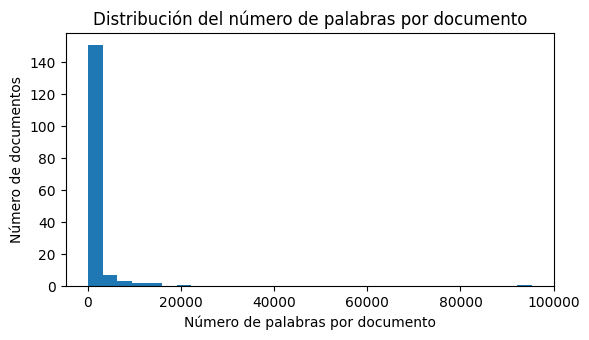

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_hist_text_length_words.png


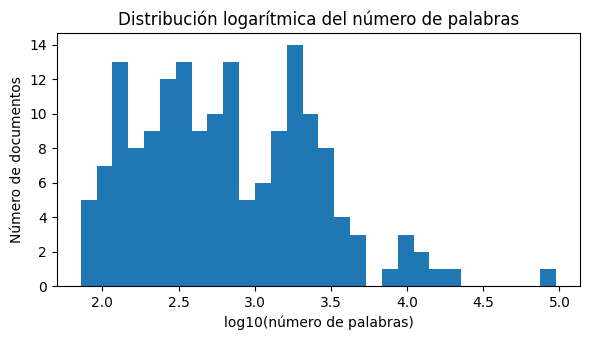

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_hist_log_text_length_words.png


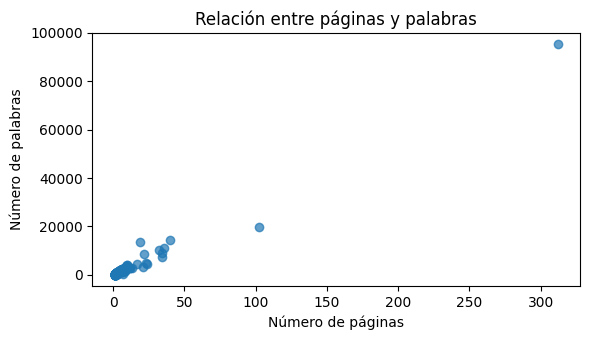

Figura guardada: /Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/figures/eda_scatter_pages_words.png


In [8]:
import matplotlib.pyplot as plt
import numpy as np

print("=== VISUALIZACIÓN DE LONGITUDES DOCUMENTALES ===\n")

# Carpeta de salida para las figuras del EDA
figures_dir = ROOT / "outputs" / "figures"
figures_dir.mkdir(parents=True, exist_ok=True)

# 1. Histograma del número de palabras por documento
plt.figure(figsize=(6, 3.5))
plt.hist(df_corpus["text_length_words"].dropna(), bins=30)
plt.xlabel("Número de palabras por documento")
plt.ylabel("Número de documentos")
plt.title("Distribución del número de palabras por documento")
plt.tight_layout()

hist_words_path = figures_dir / "eda_hist_text_length_words.png"
plt.savefig(hist_words_path, dpi=150)
plt.show()

print(f"Figura guardada: {hist_words_path}")

# 2. Histograma en escala logarítmica
# Se usa log10 para que los documentos extremos no oculten la estructura del resto del corpus.
log_words = np.log10(df_corpus["text_length_words"].dropna())

plt.figure(figsize=(6, 3.5))
plt.hist(log_words, bins=30)
plt.xlabel("log10(número de palabras)")
plt.ylabel("Número de documentos")
plt.title("Distribución logarítmica del número de palabras")
plt.tight_layout()

hist_log_words_path = figures_dir / "eda_hist_log_text_length_words.png"
plt.savefig(hist_log_words_path, dpi=150)
plt.show()

print(f"Figura guardada: {hist_log_words_path}")

# 3. Relación entre páginas y palabras
plt.figure(figsize=(6, 3.5))
plt.scatter(df_corpus["pages"], df_corpus["text_length_words"], alpha=0.7)
plt.xlabel("Número de páginas")
plt.ylabel("Número de palabras")
plt.title("Relación entre páginas y palabras")
plt.tight_layout()

scatter_path = figures_dir / "eda_scatter_pages_words.png"
plt.savefig(scatter_path, dpi=150)
plt.show()

print(f"Figura guardada: {scatter_path}")

**Lectura del bloque**

Los gráficos confirman visualmente lo que ya se veía en las estadísticas: la distribución de palabras por documento está muy concentrada en documentos cortos, pero existe una cola larga formada por unos pocos textos muy extensos.

En el histograma normal, los documentos largos comprimen visualmente al resto del corpus. Por eso se incluye también la escala logarítmica, que permite ver mejor la distribución de los documentos de tamaño medio y bajo.

La relación entre páginas y palabras es bastante lógica: en general, a más páginas, más palabras. Aun así, hay documentos que destacan claramente por tamaño, especialmente el documento de mas de 300 páginas y casi 100.000 palabras.

Estos gráficos ayudan a entender que, más adelante, algunos análisis podrán trabajar por documento completo, mientras que otros probablemente necesitarán fragmentar los textos largos.

## 5. Revisión básica de calidad del texto OCR

El corpus ya tiene texto OCR disponible para todos los documentos, pero eso no significa que todos los textos tengan la misma calidad.

En este bloque se calculan algunas métricas sencillas para detectar posibles señales de ruido:

- proporción de letras sobre el total de caracteres;
- proporción de números;
- proporción de espacios;
- proporción de mayúsculas dentro de las letras;
- proporción de líneas vacías;
- longitud media de línea;
- proporción de caracteres poco habituales.

Estas métricas permiten identificar textos que requieran de una revisión posterior.

In [9]:
print("=== REVISIÓN BÁSICA DE CALIDAD DEL TEXTO OCR ===\n")

def compute_ocr_quality_metrics(text):
    """
    Calcula métricas sencillas de calidad textual para un documento.

    No corrige el texto ni aprende parámetros globales del corpus.
    Solo resume características observables del propio documento.
    """
    text = "" if pd.isna(text) else str(text)
    n_chars = len(text)

    if n_chars == 0:
        return pd.Series({
            "alpha_ratio": 0,
            "digit_ratio": 0,
            "space_ratio": 0,
            "uppercase_ratio": 0,
            "empty_line_ratio": 0,
            "avg_line_length": 0,
            "weird_char_ratio": 0,
        })

    n_alpha = sum(char.isalpha() for char in text)
    n_digit = sum(char.isdigit() for char in text)
    n_space = sum(char.isspace() for char in text)

    letters = [char for char in text if char.isalpha()]
    n_uppercase_letters = sum(char.isupper() for char in letters)

    lines = text.splitlines()
    empty_lines = sum(line.strip() == "" for line in lines)

    non_empty_line_lengths = [len(line.strip()) for line in lines if line.strip() != ""]

    allowed_punctuation = set(
        ".,;:!?¿¡()[]{}-–—_/\\'\"“”«»%ºª°·\n\r\t "
    )

    weird_chars = [
        char for char in text
        if not (
            char.isalnum()
            or char.isspace()
            or char in allowed_punctuation
        )
    ]

    return pd.Series({
        "alpha_ratio": n_alpha / n_chars,
        "digit_ratio": n_digit / n_chars,
        "space_ratio": n_space / n_chars,
        "uppercase_ratio": (
            n_uppercase_letters / len(letters)
            if len(letters) > 0 else 0
        ),
        "empty_line_ratio": (
            empty_lines / len(lines)
            if len(lines) > 0 else 0
        ),
        "avg_line_length": (
            sum(non_empty_line_lengths) / len(non_empty_line_lengths)
            if len(non_empty_line_lengths) > 0 else 0
        ),
        "weird_char_ratio": len(weird_chars) / n_chars,
    })


quality_cols = [
    "alpha_ratio",
    "digit_ratio",
    "space_ratio",
    "uppercase_ratio",
    "empty_line_ratio",
    "avg_line_length",
    "weird_char_ratio",
]

# Evita duplicar columnas si la celda se ejecuta más de una vez
df_corpus = df_corpus.drop(columns=quality_cols, errors="ignore")

quality_metrics = df_corpus["text_full"].apply(compute_ocr_quality_metrics)
df_corpus = pd.concat([df_corpus, quality_metrics], axis=1)

print("Resumen de métricas OCR:")
display(df_corpus[quality_cols].describe().T)

print("\nDocumentos con menor proporción de caracteres alfabéticos:")
display(
    df_corpus[
        ["doc_id", "title", "pages", "text_length_words", "alpha_ratio", "digit_ratio", "weird_char_ratio", "pdf_url"]
    ]
    .sort_values("alpha_ratio", ascending=True)
    .head(10)
)

print("\nDocumentos con mayor proporción de caracteres poco habituales:")
display(
    df_corpus[
        ["doc_id", "title", "pages", "text_length_words", "alpha_ratio", "weird_char_ratio", "pdf_url"]
    ]
    .sort_values("weird_char_ratio", ascending=False)
    .head(10)
)

print("\nDocumentos con mayor proporción de mayúsculas:")
display(
    df_corpus[
        ["doc_id", "title", "pages", "text_length_words", "uppercase_ratio", "alpha_ratio", "pdf_url"]
    ]
    .sort_values("uppercase_ratio", ascending=False)
    .head(10)
)

print("\nDocumentos con mayor proporción de líneas vacías:")
display(
    df_corpus[
        ["doc_id", "title", "pages", "text_length_words", "empty_line_ratio", "avg_line_length", "pdf_url"]
    ]
    .sort_values("empty_line_ratio", ascending=False)
    .head(10)
)

=== REVISIÓN BÁSICA DE CALIDAD DEL TEXTO OCR ===

Resumen de métricas OCR:


,count,mean,std,min,25%,50%,75%,max
alpha_ratio,167.0,0.774315,0.031945,0.605882,0.759619,0.782667,0.794975,0.827997
digit_ratio,167.0,0.015484,0.014202,0.000000,0.007094,0.011487,0.019401,0.105042
space_ratio,167.0,0.174170,0.013111,0.147315,0.167819,0.171985,0.177283,0.256536
uppercase_ratio,167.0,0.179610,0.220607,0.000358,0.067494,0.101784,0.182736,1.000000
empty_line_ratio,167.0,0.404416,0.079392,0.000000,0.356654,0.424779,0.470588,0.496933
avg_line_length,167.0,117.434279,68.315287,20.673469,69.297414,114.475410,151.984028,502.428571
weird_char_ratio,167.0,0.002172,0.006305,0.000000,0.000000,0.000454,0.001183,0.060711



Documentos con menor proporción de caracteres alfabéticos:


,doc_id,title,pages,text_length_words,alpha_ratio,digit_ratio,weird_char_ratio,pdf_url
150,rtve_1710,"""Interesando comparecencia del capitán de la G...",2,236,0.605882,0.105042,0.000000,https://www.rtve.es/contenidos/documentos/23f-...
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo de...",36,11080,0.633411,0.012681,0.060711,https://www.rtve.es/contenidos/documentos/23f-...
121,rtve_1739,SECRETO: copia de telex dando instrucciones so...,3,175,0.691095,0.089054,0.000000,https://www.rtve.es/contenidos/documentos/23f-...
136,rtve_1724,RESERVADO: oficio dando cuenta toma de declara...,1,193,0.697087,0.013592,0.023301,https://www.rtve.es/contenidos/documentos/23f-...
162,rtve_1698,Documento manuscrito de posible planificación ...,7,469,0.701251,0.025018,0.009566,https://www.rtve.es/contenidos/documentos/23f-...
81,rtve_1779,"""Nota de la Brigada de Información Interior: E...",2,223,0.705096,0.033417,0.015038,https://www.rtve.es/contenidos/documentos/23f-...
166,rtve_1694,Transcripción de conversación telefónica de (p...,4,1216,0.711835,0.000472,0.000000,https://www.rtve.es/contenidos/documentos/23f-...
123,rtve_1737,SECRETO: comunicando sanción a consejeros del ...,1,218,0.713229,0.013969,0.022186,https://www.rtve.es/contenidos/documentos/23f-...
141,rtve_1719,RESERVADO: Informe de Asesoría Jurídica Genera...,2,494,0.717204,0.029749,0.009319,https://www.rtve.es/contenidos/documentos/23f-...
142,rtve_1718,RESERVADO: Hoja de servicios del Cap. Sánchez ...,1,90,0.717544,0.050877,0.005263,https://www.rtve.es/contenidos/documentos/23f-...



Documentos con mayor proporción de caracteres poco habituales:


,doc_id,title,pages,text_length_words,alpha_ratio,weird_char_ratio,pdf_url
74,rtve_1786,"""Juicio del 23-F: acotaciones al desarrollo de...",36,11080,0.633411,0.060711,https://www.rtve.es/contenidos/documentos/23f-...
84,rtve_1776,D.31._AGA-83-09301_exp._5,6,1926,0.735238,0.028275,https://www.rtve.es/contenidos/documentos/23f-...
136,rtve_1724,RESERVADO: oficio dando cuenta toma de declara...,1,193,0.697087,0.023301,https://www.rtve.es/contenidos/documentos/23f-...
123,rtve_1737,SECRETO: comunicando sanción a consejeros del ...,1,218,0.713229,0.022186,https://www.rtve.es/contenidos/documentos/23f-...
99,rtve_1761,D.17._AGMAE_R40201_Exp._215,1,169,0.728106,0.020367,https://www.rtve.es/contenidos/documentos/23f-...
36,rtve_1824,Vista oral 2/81 del Consejo Supremo de Justici...,3,1279,0.737719,0.019966,https://www.rtve.es/contenidos/documentos/23f-...
81,rtve_1779,"""Nota de la Brigada de Información Interior: E...",2,223,0.705096,0.015038,https://www.rtve.es/contenidos/documentos/23f-...
163,rtve_1697,"""Documentación con una presunta planificación ...",23,4882,0.754207,0.010635,https://www.rtve.es/contenidos/documentos/23f-...
162,rtve_1698,Documento manuscrito de posible planificación ...,7,469,0.701251,0.009566,https://www.rtve.es/contenidos/documentos/23f-...
141,rtve_1719,RESERVADO: Informe de Asesoría Jurídica Genera...,2,494,0.717204,0.009319,https://www.rtve.es/contenidos/documentos/23f-...



Documentos con mayor proporción de mayúsculas:


,doc_id,title,pages,text_length_words,uppercase_ratio,alpha_ratio,pdf_url
102,rtve_1758,D.14._AGMAE_R39017_Exp._4,2,650,1.000000,0.801230,https://www.rtve.es/contenidos/documentos/23f-...
155,rtve_1705,Referencias en los medios de comunicación soci...,1,334,1.000000,0.801737,https://www.rtve.es/contenidos/documentos/23f-...
121,rtve_1739,SECRETO: copia de telex dando instrucciones so...,3,175,1.000000,0.691095,https://www.rtve.es/contenidos/documentos/23f-...
116,rtve_1744,D.2._AGMAE_R39017_Exp._4,1,354,1.000000,0.778527,https://www.rtve.es/contenidos/documentos/23f-...
52,rtve_1808,Reacciones ante la sentencia 23-F. Declaracion...,2,397,1.000000,0.782667,https://www.rtve.es/contenidos/documentos/23f-...
54,rtve_1806,Comentarios sobre la sentencia del 23-F. Cuart...,1,240,1.000000,0.761174,https://www.rtve.es/contenidos/documentos/23f-...
107,rtve_1753,D.10._AGMAE_R39017_Exp._4,1,196,0.909990,0.803018,https://www.rtve.es/contenidos/documentos/23f-...
159,rtve_1701,Télex interiores y de agencias recibidos en 2ª...,102,19857,0.903683,0.766593,https://www.rtve.es/contenidos/documentos/23f-...
88,rtve_1772,D.27._AGA-83-09301_exp._5,1,120,0.838499,0.752147,https://www.rtve.es/contenidos/documentos/23f-...
105,rtve_1755,D.12._AGMAE_R39017_Exp._4,1,113,0.838078,0.786014,https://www.rtve.es/contenidos/documentos/23f-...



Documentos con mayor proporción de líneas vacías:


,doc_id,title,pages,text_length_words,empty_line_ratio,avg_line_length,pdf_url
39,rtve_1821,Vista oral 2/81 del Consejo Supremo de Justici...,7,2579,0.496933,190.390244,https://www.rtve.es/contenidos/documentos/23f-...
64,rtve_1796,Informe sobre la participación de miembros de ...,8,1753,0.496689,131.763158,https://www.rtve.es/contenidos/documentos/23f-...
14,rtve_1846,Vista oral 2/81 del Consejo Supremo de Justici...,6,2099,0.496124,189.323077,https://www.rtve.es/contenidos/documentos/23f-...
27,rtve_1833,Vista oral 2/81 del Consejo Supremo de Justici...,10,2775,0.495050,155.696078,https://www.rtve.es/contenidos/documentos/23f-...
32,rtve_1828,Vista oral 2/81 del Consejo Supremo de Justici...,7,2411,0.494444,154.890110,https://www.rtve.es/contenidos/documentos/23f-...
37,rtve_1823,Vista oral 2/81 del Consejo Supremo de Justici...,5,1670,0.494118,235.302326,https://www.rtve.es/contenidos/documentos/23f-...
9,rtve_1851,Vista oral 2/81 del Consejo Supremo de Justici...,5,1165,0.493827,168.121951,https://www.rtve.es/contenidos/documentos/23f-...
66,rtve_1794,Resumen de la actuación del Departamento de De...,2,542,0.490196,126.461538,https://www.rtve.es/contenidos/documentos/23f-...
12,rtve_1848,Vista oral 2/81 del Consejo Supremo de Justici...,2,676,0.488372,184.636364,https://www.rtve.es/contenidos/documentos/23f-...
19,rtve_1841,Vista oral 2/81 del Consejo Supremo de Justici...,5,1630,0.488372,141.803030,https://www.rtve.es/contenidos/documentos/23f-...


**Lectura del bloque**

El texto OCR parece utilizable para un análisis general: todos los documentos tienen texto y la proporción media de caracteres alfabéticos es del 77,4 %. No se aprecia un fallo estructural de extracción.

Aun así, hay documentos con señales de ruido: menor proporción de letras, más números, más caracteres poco habituales o uso intensivo de mayúsculas. Esto puede deberse al formato original de los documentos, códigos administrativos, tablas, telegramas, manuscritos o artefactos propios del OCR.

En este punto no se corrige ni se elimina ningún documento. La revisión solo sirve para saber que el corpus es aprovechable, pero que algunos mini casos deberán tratar el ruido textual con más cuidado.

## 6. Cobertura institucional básica

El siguiente paso es revisar qué información institucional aporta la comparación con La Moncloa.

RTVE se mantiene como fuente principal del corpus, porque es donde tenemos el inventario, el texto OCR y los enlaces de trabajo. La Moncloa se usa como fuente de contraste para entender la procedencia institucional de los documentos.

En este bloque solo se revisan recuentos generales. No se construye todavía una variable objetivo definitiva ni se preparan features para modelos.

In [10]:
print("=== COBERTURA INSTITUCIONAL BÁSICA ===\n")

comparison_cols = [
    "matched_rtve_doc_id",
    "moncloa_id",
    "moncloa_section",
    "moncloa_subsection",
    "final_match_status",
]

source_comparison_small = (
    source_comparison[comparison_cols]
    .rename(columns={"matched_rtve_doc_id": "doc_id"})
    .copy()
)

df_corpus = df_corpus.drop(
    columns=[
        "moncloa_id",
        "moncloa_section",
        "moncloa_subsection",
        "final_match_status",
        "coverage_moncloa",
    ],
    errors="ignore"
)

df_corpus = df_corpus.merge(
    source_comparison_small,
    on="doc_id",
    how="left",
    validate="one_to_one"
)

df_corpus["coverage_moncloa"] = df_corpus["moncloa_id"].notna()

print("Documentos RTVE con y sin correspondencia en La Moncloa:")
display(
    df_corpus["coverage_moncloa"]
    .map({True: "con_match_moncloa", False: "solo_rtve"})
    .value_counts()
    .rename_axis("coverage_moncloa")
    .reset_index(name="n_documentos")
)

print("\nDistribución por sección Moncloa:")
display(
    df_corpus["moncloa_section"]
    .fillna("sin_match_moncloa")
    .value_counts()
    .rename_axis("moncloa_section")
    .reset_index(name="n_documentos")
)

print("\nDistribución por subsección Moncloa:")
display(
    df_corpus["moncloa_subsection"]
    .fillna("sin_subseccion_o_sin_match")
    .value_counts()
    .rename_axis("moncloa_subsection")
    .reset_index(name="n_documentos")
)

print("\nEstado del matching:")
display(
    df_corpus["final_match_status"]
    .fillna("sin_match_moncloa")
    .value_counts()
    .rename_axis("final_match_status")
    .reset_index(name="n_documentos")
)

=== COBERTURA INSTITUCIONAL BÁSICA ===

Documentos RTVE con y sin correspondencia en La Moncloa:


,coverage_moncloa,n_documentos
0,con_match_moncloa,155
1,solo_rtve,12



Distribución por sección Moncloa:


,moncloa_section,n_documentos
0,defensa,108
1,interior,28
2,exteriores,19
3,sin_match_moncloa,12



Distribución por subsección Moncloa:


,moncloa_subsection,n_documentos
0,cni,84
1,sin_subseccion_o_sin_match,55
2,guardia-civil,11
3,policia,10
4,archivo,7



Estado del matching:


,final_match_status,n_documentos
0,high_confidence_match,150
1,sin_match_moncloa,12
2,manual_match,5


**Lectura del bloque**

La comparación con La Moncloa cubre la mayor parte del corpus: 155 de los 167 documentos RTVE tienen correspondencia identificada. Los 12 documentos restantes aparecen únicamente en RTVE dentro de esta comparación.

La sección con más documentos es `defensa`, con 108 registros, seguida de `interior`, con 28, y `exteriores`, con 19. Esto muestra que el corpus no está equilibrado por procedencia institucional, algo que habrá que tener en cuenta si más adelante se plantea una clasificación supervisada por sección.

A nivel de subsección, destaca `cni`, con 84 documentos. También aparecen `guardia-civil`, `policia` y `archivo`. Hay 55 documentos sin subsección o sin match, por lo que la subsección no debería tratarse como una variable completa sin revisar antes su cobertura.

El matching parece bastante sólido: 150 documentos aparecen como `high_confidence_match` y 5 como `manual_match`. Para este EDA general, esta información es suficiente para entender la cobertura institucional. No se construye todavía una etiqueta final ni se usan estas columnas como variables de modelado.

## 7. Revisión de metadatos auxiliares

Además del texto OCR completo, el corpus incluye algunos campos auxiliares como `title`, `summary` y `keywords`.

Antes de usarlos en análisis posteriores, conviene comprobar qué contienen realmente. Estos campos pueden ser útiles para explorar el corpus, pero no necesariamente tienen la misma calidad ni el mismo significado que el texto completo.

En este bloque se revisa:

- si `summary` y `keywords` están completos;
- la longitud de estos campos;
- si los summaries parecen truncados;
- si las keywords son palabras clave semánticas o más bien referencias administrativas;
- si los títulos contienen años explícitos.

In [12]:
print("=== REVISIÓN DE METADATOS AUXILIARES ===\n")

metadata_cols = ["title", "summary", "keywords"]

# Cobertura de campos auxiliares
metadata_coverage = []

for col in metadata_cols:
    n_with_value = df_corpus[col].notna().sum()
    n_empty = df_corpus[col].fillna("").str.strip().eq("").sum()
    
    metadata_coverage.append({
        "campo": col,
        "documentos_con_valor": n_with_value,
        "documentos_vacios": n_empty,
        "porcentaje_con_valor": round(n_with_value / len(df_corpus) * 100, 2),
    })

metadata_coverage = pd.DataFrame(metadata_coverage)

print("Cobertura de campos auxiliares:")
display(metadata_coverage)

# Longitud de summary y keywords
df_corpus["summary_length_chars"] = df_corpus["summary"].fillna("").str.len()
df_corpus["summary_length_words"] = df_corpus["summary"].fillna("").str.split().str.len()

df_corpus["keywords_length_chars"] = df_corpus["keywords"].fillna("").str.len()
df_corpus["keywords_length_words"] = df_corpus["keywords"].fillna("").str.split().str.len()

print("\nResumen de longitud de summary:")
display(
    df_corpus[["summary_length_chars", "summary_length_words"]]
    .describe()
    .T
)

print("\nResumen de longitud de keywords:")
display(
    df_corpus[["keywords_length_chars", "keywords_length_words"]]
    .describe()
    .T
)

# Comprobación sencilla de summaries truncados
df_corpus["summary_ends_with_ellipsis"] = (
    df_corpus["summary"]
    .fillna("")
    .str.strip()
    .str.endswith("...")
)

print("\nSummaries terminados en '...':")
display(
    df_corpus["summary_ends_with_ellipsis"]
    .value_counts()
    .rename_axis("summary_ends_with_ellipsis")
    .reset_index(name="n_documentos")
)

# Keywords con patrones de códigos o fechas administrativas
df_corpus["keywords_has_date_pattern"] = (
    df_corpus["keywords"]
    .fillna("")
    .str.contains(r"\d{1,2}[-/.]\d{1,2}[-/.]\d{2,4}", regex=True)
)

df_corpus["keywords_has_admin_reference"] = (
    df_corpus["keywords"]
    .fillna("")
    .str.contains(r"\b(?:C/|SG|Ref|N/|Exp|AGMAE|AGA)\b", regex=True, case=False)
)

print("\nKeywords con fecha o referencia administrativa:")
display(
    pd.DataFrame({
        "indicador": [
            "keywords_has_date_pattern",
            "keywords_has_admin_reference",
        ],
        "n_documentos": [
            df_corpus["keywords_has_date_pattern"].sum(),
            df_corpus["keywords_has_admin_reference"].sum(),
        ],
    })
)

print("\nEjemplos de keywords:")
display(
    df_corpus[
        ["doc_id", "title", "keywords", "keywords_length_words"]
    ]
    .head(15)
)

# Años explícitos en título
df_corpus["title_years"] = (
    df_corpus["title"]
    .fillna("")
    .str.findall(r"\b(19\d{2}|20\d{2})\b")
)

df_corpus["n_title_years"] = df_corpus["title_years"].str.len()
df_corpus["title_main_year"] = df_corpus["title_years"].apply(
    lambda years: int(years[0]) if len(years) > 0 else pd.NA
)

print("\nDocumentos con año explícito en el título:")
display(
    df_corpus["n_title_years"]
    .gt(0)
    .value_counts()
    .rename_axis("has_title_year")
    .reset_index(name="n_documentos")
)

print("\nDistribución de años detectados en títulos:")
display(
    df_corpus["title_main_year"]
    .value_counts(dropna=False)
    .sort_index()
    .rename_axis("title_main_year")
    .reset_index(name="n_documentos")
)

=== REVISIÓN DE METADATOS AUXILIARES ===

Cobertura de campos auxiliares:


,campo,documentos_con_valor,documentos_vacios,porcentaje_con_valor
0,title,167,0,100.0
1,summary,167,0,100.0
2,keywords,167,0,100.0



Resumen de longitud de summary:


,count,mean,std,min,25%,50%,75%,max
summary_length_chars,167.0,303.000000,0.000000,303.0,303.0,303.0,303.0,303.0
summary_length_words,167.0,48.568862,3.050734,39.0,47.0,49.0,51.0,56.0



Resumen de longitud de keywords:


...

,doc_id,title,keywords,keywords_length_words
0,rtve_1860,Vista oral 2/81 del Consejo Supremo de Justici...,C/SG/2820/20-02-82 DTOR. Vista oral 2/81,5
1,rtve_1859,Vista oral 2/81 del Consejo Supremo de Justici...,C/SG/2896/22-02-82 Vista oral 2/81 Consejo Sup...,9
2,rtve_1858,Vista oral 2/81 del Consejo Supremo de Justici...,C/SG/2992/24-02-82 Vista Oral 2/81 Consejo Sup...,9
3,rtve_1857,Vista oral 2/81 del Consejo Supremo de Justici...,C/SG/3.081/25-02-82 Vista Oral 2/81 Consejo Su...,9
4,rtve_1856,Vista oral 2/81 del Consejo Supremo de Justici...,C/SG/3.249/26-02-82 SG Consejo Supremo de Just...,7
5,rtve_1855,Información integrada (11 de marzo de 1982).,N/RFA:C/DI/ 4132 /11-3-82 Vista pública Causa ...,7
6,rtve_1854,Información integrada (16 de marzo de 1982).,C/DI/4339/16-03-82 DTOR. vista pública,4
7,rtve_1853,Vista oral 2/81 del Consejo Supremo de Justici...,C/SG/3.464/02-03-82 D'OR Vista oral,4
8,rtve_1852,Vista oral 2/81 del Consejo Supremo de Justici...,C/SG/3644/05-03-82 Vista oral Causa 2/81,5
9,rtve_1851,Vista oral 2/81 del Consejo Supremo de Justici...,C/SG/3835/08-03-82 NOTA INFORMATIVA VISTA ORAL,5



Documentos con año explícito en el título:


,has_title_year,n_documentos
0,True,89
1,False,78



Distribución de años detectados en títulos:


,title_main_year,n_documentos
0,1975,1
1,1978,2
2,1981,21
3,1982,62
4,1983,2
5,1987,1
6,<NA>,78


**Lectura del bloque**

Los campos auxiliares están completos: todos los documentos tienen `title`, `summary` y `keywords`. Esto es positivo, pero no significa que todos estos campos sean igual de útiles para analizar el contenido.

El campo `summary` tiene exactamente 303 caracteres en todos los documentos y todos los registros terminan en `...`. Esto indica que probablemente se trata de un texto recortado o limitado por la fuente, no de un resumen completo del documento. Puede servir como apoyo para una lectura rápida, pero el análisis de contenido debería basarse principalmente en `text_full`.

El campo `keywords` también está completo, aunque muchos valores no son palabras clave semánticas limpias. En varios casos aparecen fechas, códigos internos o referencias administrativas. En concreto, 58 documentos tienen patrones de fecha en `keywords` y 46 contienen referencias administrativas.

En los títulos se detecta al menos un año explícito en 89 documentos, mientras que 78 no tienen año en el título. Por tanto, el título permite una primera aproximación temporal, pero no basta para construir una cronología completa del corpus.

## 8. Señal textual general

Como cierre del EDA, se revisa de forma sencilla el vocabulario más frecuente del corpus.

El objetivo es comprobar si el texto OCR contiene señales coherentes con el dominio documental del 23-F: cargos militares, instituciones, actores, lugares y expresiones repetidas.

Para mantener este análisis general y legible, se calculan únicamente términos frecuentes y bigramas frecuentes. Análisis más específicos, como TF-IDF, embeddings, clustering, topic modeling o extracción de entidades, se desarrollarán dentro de cada mini caso.

In [15]:
import re
from collections import Counter

print("=== SEÑAL TEXTUAL GENERAL ===\n")

# Stopwords básicas para una lectura exploratoria del vocabulario.
# No es una limpieza final para modelos, solo una forma de quitar ruido evidente del EDA.
basic_stopwords = {
    "de", "la", "el", "en", "y", "a", "los", "del", "se", "las", "por", "un", "una",
    "con", "para", "que", "su", "al", "lo", "como", "más", "o", "sus", "le", "ha",
    "es", "no", "este", "esta", "estos", "estas", "son", "entre", "sobre", "también",
    "ser", "han", "fue", "sin", "desde", "durante", "parte", "tras", "ya", "todo",
    "todos", "todas", "donde", "cuando", "hasta", "muy", "hay", "había", "habian",
    "habían", "era", "eran", "está", "estan", "están", "estar", "estaba", "estaban",
    "pero", "porque", "qué", "que", "eso", "esa", "ese", "esas", "esos", "así",
    "bien", "bueno", "pues", "nada", "ver", "voy", "va", "van", "puede", "pueden",
    "tiene", "tienen", "dicho", "mismo", "misma", "modo", "forma", 
    "sido", "ahora", "aquí", "alli", "allí", "dos", "otra", "vez",
    "the", "and", "of", "to", "in", "for", "on", "with", "as", "by", "from",
}

# Términos poco útiles para interpretar temas.
# Algunos son artefactos de formato o palabras demasiado genéricas en este corpus.
extra_stopwords = {
    "documento", "documentos", "nota", "informe", "vista", "oral", "página",
    "páginas", "resumen", "global", "asunto", "ref", "nref", "img", "jpeg",
    "sesion", "sesión", "desarrollo", "correspondiente", "pasó", "paso",
    "xerocopia", "sección", "dir", "gral", "dtor",
}

stopwords = basic_stopwords | extra_stopwords

def tokenize_text(text):
    """
    Tokenización sencilla para EDA:
    - pasa a minúsculas;
    - conserva letras con tildes y números;
    - elimina tokens muy cortos y stopwords.
    """
    text = "" if pd.isna(text) else str(text).lower()
    tokens = re.findall(r"[a-záéíóúüñ0-9]+", text)
    
    clean_tokens = []
    for token in tokens:
        if len(token) <= 2:
            continue
        if token in stopwords:
            continue
        clean_tokens.append(token)
    
    return clean_tokens

df_corpus["tokens_eda"] = df_corpus["text_full"].apply(tokenize_text)
df_corpus["n_tokens_eda"] = df_corpus["tokens_eda"].apply(len)

print("Resumen de tokens tras limpieza básica para EDA:")
display(df_corpus["n_tokens_eda"].describe().to_frame().T)

# Términos frecuentes globales
all_tokens = []
for tokens in df_corpus["tokens_eda"]:
    all_tokens.extend(tokens)

top_terms_df = pd.DataFrame(
    Counter(all_tokens).most_common(30),
    columns=["term", "frequency"]
)

print("\nTop 30 términos más frecuentes:")
display(top_terms_df)

# Bigramas frecuentes globales
all_bigrams = []

for tokens in df_corpus["tokens_eda"]:
    for first, second in zip(tokens, tokens[1:]):
        all_bigrams.append((first, second))

top_bigrams_df = pd.DataFrame(
    [(" ".join(bigram), freq) for bigram, freq in Counter(all_bigrams).most_common(30)],
    columns=["bigram", "frequency"]
)

print("\nTop 30 bigramas más frecuentes:")
display(top_bigrams_df)

=== SEÑAL TEXTUAL GENERAL ===

Resumen de tokens tras limpieza básica para EDA:


,count,mean,std,min,25%,50%,75%,max
n_tokens_eda,167.0,927.54491,2781.440248,39.0,124.5,295.0,868.0,32553.0



Top 30 términos más frecuentes:


,term,frequency
0,general,1891
1,coronel,873
2,civil,836
3,teniente,744
4,congreso,711
5,guardia,704
6,tejero,699
7,militar,657
8,capitán,603
9,armada,586



Top 30 bigramas más frecuentes:


,bigram,frequency
0,guardia civil,655
1,teniente coronel,381
2,general armada,316
3,coronel tejero,252
4,teniente general,228
5,tcol tejero,202
6,general milans,156
7,milans bosch,147
8,justicia militar,139
9,comandante pardo,111


**Lectura del bloque**

La revisión básica del vocabulario muestra que el texto OCR contiene señales coherentes con el dominio del corpus. Entre los términos más frecuentes aparecen cargos militares, instituciones, actores y lugares vinculados al 23-F, como `general`, `coronel`, `guardia`, `tejero`, `militar`, `armada`, `rey`, `madrid` o `gobierno`.

Los bigramas también son interpretables. Aparecen expresiones como `guardia civil`, `teniente coronel`, `general armada`, `coronel tejero`, `justicia militar`, `consejo supremo` o `fuerzas armadas`. Esto indica que el texto completo conserva información útil para análisis posteriores.

Este bloque no pretende hacer una limpieza final del texto ni construir variables para modelos. Solo sirve para comprobar que el corpus tiene contenido textual aprovechable. Los análisis más específicos, como TF-IDF, embeddings, clustering, extracción de entidades o búsqueda semántica, deberán desarrollarse dentro de cada mini caso.

## 9. Conclusiones del EDA general

El corpus principal queda formado por 167 documentos RTVE, todos ellos con texto OCR disponible. No se detectan duplicados por `doc_id`, textos vacíos ni documentos del inventario sin texto asociado.

La principal característica del corpus es su heterogeneidad. La mayoría de documentos son relativamente cortos, pero existen algunos textos muy extensos que elevan mucho la media de palabras y páginas. Esta diferencia deberá tenerse en cuenta en fases posteriores, especialmente si se trabaja con búsqueda semántica, extracción de entidades o análisis por fragmentos.

La calidad del OCR parece suficiente para continuar con análisis de texto, aunque existen documentos con señales de ruido: uso intensivo de mayúsculas, caracteres poco habituales, códigos administrativos, tablas o formatos propios de documentación histórica. Por este motivo, cada mini caso deberá decidir su propia estrategia de limpieza textual.

La comparación con La Moncloa aporta una primera lectura institucional del corpus. La mayoría de documentos tienen correspondencia con esta fuente, pero no todos. Además, la distribución por secciones no está equilibrada: predominan los documentos de `defensa`, seguidos por `interior` y `exteriores`.

Los campos auxiliares `summary` y `keywords` están completos, pero deben usarse con cautela. Los summaries parecen estar recortados y las keywords incluyen con frecuencia fechas o referencias administrativas. Por tanto, el campo principal para análisis de contenido seguirá siendo `text_full`.

La revisión básica del vocabulario confirma que el corpus contiene señales textuales coherentes con el dominio del 23-F. Aparecen términos y expresiones vinculadas a cargos militares, instituciones, actores y acontecimientos relevantes.

Este notebook queda como EDA general del corpus. No realiza modelado ni genera transformaciones finales para entrenamiento. Los mini casos posteriores deberán construir sus propios datasets, limpiezas y pipelines, evitando ajustar transformaciones con información de validación o test.

In [17]:
print("=== GUARDADO DE TABLA DESCRIPTIVA DEL EDA ===\n")

processed_dir = ROOT / "data" / "processed"
outputs_tables_dir = ROOT / "outputs" / "tables"

processed_dir.mkdir(parents=True, exist_ok=True)
outputs_tables_dir.mkdir(parents=True, exist_ok=True)

# Se guarda una tabla descriptiva enriquecida.
# No es una matriz final de entrenamiento.
# Cada mini caso deberá construir su propio dataset de modelado a partir de sus necesidades.

columns_to_exclude = [
    "tokens_eda",
    "title_years",
]

df_eda_descriptive = df_corpus.drop(columns=columns_to_exclude, errors="ignore")

eda_descriptive_path = processed_dir / "rtve_corpus_eda_descriptive.csv"
eda_descriptive_output_path = outputs_tables_dir / "rtve_corpus_eda_descriptive.csv"

df_eda_descriptive.to_csv(eda_descriptive_path, index=False)
df_eda_descriptive.to_csv(eda_descriptive_output_path, index=False)

print(f"Tabla descriptiva guardada en:\n{eda_descriptive_path}")
print(f"\nCopia guardada en outputs:\n{eda_descriptive_output_path}")
print(f"\nDimensiones finales: {df_eda_descriptive.shape}")

=== GUARDADO DE TABLA DESCRIPTIVA DEL EDA ===

Tabla descriptiva guardada en:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/data/processed/rtve_corpus_eda_descriptive.csv

Copia guardada en outputs:
/Users/gabrielrezola/TrabajoML/RepositoriosGitHub/Proyecto-Machine-Learning-UNAV---Bayesianos-de-los-Ca-dos/outputs/tables/rtve_corpus_eda_descriptive.csv

Dimensiones finales: (167, 40)
